# Multi-Agent Observability & Evaluation — Demo

### A production-style showcase of how to *see* and *measure* AI agents

---

## What is this?

An end-to-end framework that runs AI **web-navigation agents** against the
[Mind2Web](https://osu-nlp-group.github.io/Mind2Web/) benchmark (NeurIPS 2023) and
instruments every step with **OpenTelemetry-compliant tracing** and a rigorous
**multi-layer evaluation** stack. It compares a **single ReAct agent** against a
**Multi-Agent System (MAS)** built on the supervisor pattern:

> **Supervisor → Planner → Navigator → Validator**

## Why does it matter?

As autonomous agents move into production, two questions become mission-critical:

1. **Observability** — *Can you see what the agent did?* Every LLM call, routing
   decision, and tool invocation is captured as an OTel span you can ship to
   Datadog, Splunk, Phoenix, or Langfuse — an auditable record of *how* a result
   was reached, not just *that* it finished.
2. **Evaluation** — *Can you prove it did the right thing?* A hybrid scorer
   (deterministic rules + LLM-as-judge), tool-selection correctness, and safety
   checks quantify quality, cost, latency, and health.

## The story this demo tells

A single agent is simple and cheap, but it has to plan, act, and self-check all at
once. A **Multi-Agent System decomposes the work** — a Planner decides the steps, a
Navigator executes them with tools, and a Validator independently checks the result.
On harder, multi-step tasks this division of labor can **lift task quality** at the
cost of more tokens and latency. This notebook runs **both systems on the same
tasks** and puts the trade-off side by side, so you can decide *when orchestration is
worth it*.

## Value

- **Provider-agnostic** — Azure OpenAI, OpenAI, Ollama, Groq, Together (via `.env`)
- **Audit-ready** — OTLP trace export + per-agent cost attribution
- **Coding-light** — all logic lives in `src/`; this notebook is the narrative
- **Reusable** — swap in your own agents, tools, or benchmark

---


## Step 1 — Install & Import

All implementation lives in `src/` — this notebook stays deliberately coding-light.

| Symbol | Role |
|---|---|
| `Config` | Provider-agnostic LLM factory + cost table |
| `TracingManager`, `HierarchicalTracer` | Per-task trace + OpenTelemetry span tree |
| `CostTracker`, `HealthMonitor` | Cost rollups + rolling-window health |
| `SafetyValidator` | PII / injection / harmful-content checks |
| `load_mind2web`, `Mind2WebTask` | Benchmark loader + task object |
| `create_baseline_agent`, `run_agent` | Single ReAct agent |
| `create_multi_agent`, `run_multi_agent` | Supervisor → Planner → Navigator → Validator |
| `evaluate_batch` | Runs N tasks through either system → tidy DataFrame |
| `HybridEvaluator`, `ToolCorrectnessEval` | Scoring engines |
| `plot_*` | Dashboards, trace tree, single-vs-multi comparison |

> `%autoreload 2` is enabled, so edits under `src/` take effect without a kernel restart.

In [1]:
# Uncomment on first run:
# !pip install -r requirements.txt

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

from src import (
    Config,
    TracingManager, HierarchicalTracer,
    CostTracker, HealthMonitor,
    SafetyValidator,
    load_mind2web,
    Mind2WebTask,
    create_baseline_agent, run_agent,
    create_multi_agent, run_multi_agent,
    evaluate_batch,
    HybridEvaluator, ToolCorrectnessEval,
    plot_eval_dashboard, plot_trace_tree, plot_telemetry_dashboard,
    plot_dataset_overview, plot_baseline_vs_multi,
)

print('✅ All imports successful')

✅ All imports successful


## Step 2 — Configuration

Settings come from your `.env` (copied from `.env.example`) — **no hardcoded
credentials**. Provider is auto-detected: `OPENAI_API_VERSION` set → Azure OpenAI;
blank → OpenAI / Ollama / Groq / any compatible endpoint.

**Per-specialist models (optional).** The multi-agent system can give each role its
own model. By default Planner/Navigator/Supervisor use `AGENT_MODEL` and Validator
uses `JUDGE_MODEL`, but you can override in `.env` — e.g. a cheap Planner and a
strong Navigator:

```
PLANNER_MODEL=gpt-4o-mini
NAVIGATOR_MODEL=gpt-4o
VALIDATOR_MODEL=gpt-4.1
```

> **Tip:** use a *different* model for the judge/validator than the agent to reduce
> self-evaluation bias.

In [2]:
Config.setup_dirs()

print('Provider:    ', 'Azure OpenAI' if Config.API_VERSION else 'OpenAI / compatible')
print('Agent model: ', Config.AGENT_MODEL)
print('Judge model: ', Config.JUDGE_MODEL)
print('MAS models:  ', {
    'supervisor': Config.SUPERVISOR_MODEL, 'planner': Config.PLANNER_MODEL,
    'navigator':  Config.NAVIGATOR_MODEL,  'validator': Config.VALIDATOR_MODEL,
})
print('Pass threshold:', Config.EVAL_PASS_THRESHOLD)
print('Output dir:    ', Config.OUTPUT_DIR)

Provider:     Azure OpenAI
Agent model:  gpt-5-4-20260305-gs
Judge model:  gpt-4-1-20250414-gs
MAS models:   {'supervisor': 'gpt-5-4-20260305-gs', 'planner': 'gpt-5-4-20260305-gs', 'navigator': 'gpt-5-4-20260305-gs', 'validator': 'gpt-4-1-20250414-gs'}
Pass threshold: 0.7
Output dir:     outputs


## Step 3 — Verify LLM Connectivity

A quick smoke test before spending time on the full pipeline — one tiny call to the
agent model and one to the judge model. Catches auth errors, wrong deployment names,
and IP-allowlist blocks *early*. If either errors, fix `.env` (see
[`docs/provider-setup.md`](docs/provider-setup.md)) before continuing.

In [3]:
from langchain_core.messages import HumanMessage

agent_llm = Config.create_llm(role='agent')
judge_llm = Config.create_llm(role='judge')

print('Agent LLM ✅:', agent_llm.invoke([HumanMessage(content='Say hello in 5 words.')]).content.strip())
print('Judge LLM ✅:', judge_llm.invoke([HumanMessage(content='Reply with the single digit 1.')]).content.strip())

Agent LLM ✅: Hello there, nice to meet you.
Judge LLM ✅: 1


## Step 4 — Load the Mind2Web Benchmark (Test Data)

[**Mind2Web**](https://osu-nlp-group.github.io/Mind2Web/) (NeurIPS 2023, OSU NLP) is
the first large-scale benchmark for agents that follow natural-language instructions
to navigate **real websites** — 2,000+ tasks across 137 sites and 31 domains.

We stream `osunlp/Multimodal-Mind2Web` from HuggingFace, keeping only lightweight
**text metadata** (skipping HTML/screenshots). Each task has a `confirmed_task`, a
`website`/`domain`, and `action_reprs` — the **gold reference action sequence** used
to score tool correctness. First run caches ~300 tasks to `outputs/data/`.

> The framework scores the agent's *plan* against these references in a safe
> sandbox — it does not drive a live browser against the real site.

In [4]:
raw_tasks = load_mind2web(Config.DATA_DIR, target_tasks=Config.MIND2WEB_TARGET_TASKS)
print(f'Loaded {len(raw_tasks)} tasks. Sample: {raw_tasks[0]["confirmed_task"][:90]}')

Using cached dataset: 300 tasks (outputs/data/mind2web_train.jsonl)
Loaded 300 tasks. Sample: rent a car in Brooklyn - Central, NY on from April 9 to April 15.


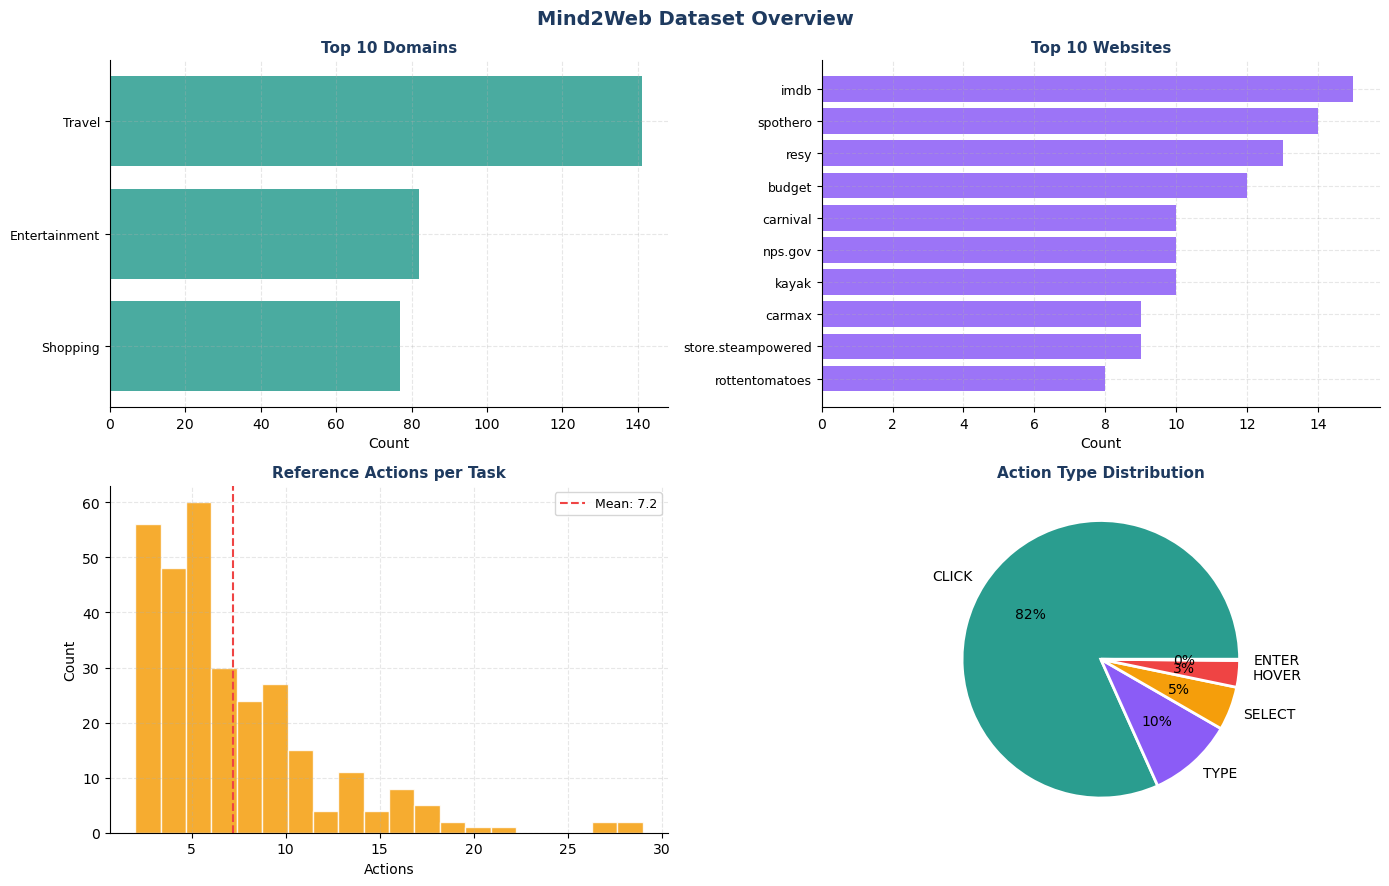

In [5]:
fig = plot_dataset_overview(raw_tasks, save_path=Config.OUTPUT_DIR / 'dataset_overview.png')

## Step 5 — Build Both Systems

We initialize the shared observability/monitoring components, then build **both
architectures** so they can be compared on identical tasks.

**Single-Agent (baseline)** — one ReAct agent with all 11 hybrid tools. Plans, acts,
and answers in a single loop.

**Multi-Agent System (MAS)** — the supervisor pattern, each specialist with its own
role, model, and OTel span:

| Specialist | Role | Tools? |
|---|---|---|
| **Supervisor** | Routes the pipeline | no |
| **Planner** | Decomposes task into 3–5 steps | no |
| **Navigator** | Executes the plan with tools | **yes** |
| **Validator** | Independently judges completion/quality | no |

**Tools** (`src/tools.py`) are *hybrid real + mock*: READ tools fetch live data when
keys are present (Tavily) else realistic mocks; WRITE tools (book/purchase/submit)
are **always mocked** — no real transactions.

In [6]:
# Shared observability + monitoring
tracing_manager = TracingManager()
hier_tracer     = HierarchicalTracer()
cost_tracker    = CostTracker()
health_monitor  = HealthMonitor(window_size=50)

# Both systems
agent, judge_llm = create_baseline_agent(Config)
multi_agents     = create_multi_agent(Config)

# Shared evaluator
evaluator = HybridEvaluator(judge_llm,
                            pass_threshold=Config.EVAL_PASS_THRESHOLD,
                            rule_weight=Config.RULE_WEIGHT,
                            llm_weight=Config.LLM_WEIGHT)

print('✅ Single-agent + Multi-agent systems ready')
print('   MAS specialists:', list(multi_agents['models'].keys()))

✅ Single-agent + Multi-agent systems ready
   MAS specialists: ['supervisor', 'planner', 'navigator', 'validator']


## Step 6 — Dry Run (1 task, both systems)

Verify the full pipeline on a single task for **each** architecture before the batch.
Both emit an OpenTelemetry span tree (`task.execute → … → tool.execute`). Note how the
multi-agent run shows the per-specialist breakdown in its reasoning steps.

In [7]:
task = Mind2WebTask.from_dict(raw_tasks[0], idx=0)

# Single agent
out_s, tr_s = run_agent(task, agent, tracing_manager, Config, hier_tracer)
print(f'[Single]  latency={tr_s.latency_ms:.0f}ms  tools={len(tr_s.tool_calls)}  cost=${tr_s.total_cost:.5f}')

# Multi-agent
out_m, tr_m = run_multi_agent(task, multi_agents, hier_tracer, tracing_manager, Config)
print(f'[MAS]     latency={tr_m.latency_ms:.0f}ms  tools={len(tr_m.tool_calls)}  cost=${tr_m.total_cost:.5f}')
print('  per-agent:', tr_m.reasoning_steps)

# Reset so the dry run does not pollute the batch metrics
tracing_manager.reset(); health_monitor.reset(); hier_tracer.reset()

[Single]  latency=17558ms  tools=10  cost=$0.01140
[MAS]     latency=16591ms  tools=13  cost=$0.00951
  per-agent: ['Planner: 242 tok / $0.00144', 'Navigator: 13 tools, 778 tok / $0.00615', 'Validator: YES/HIGH, $0.00192']


## Step 7 — Single-Agent Baseline (N tasks)

Run the baseline ReAct agent over `QUICK_TEST_N` tasks. `evaluate_batch` applies the
full evaluation stack per task — task completion (rule + LLM judge), tool correctness
(precision/recall/F1), safety, plus cost/latency/health — and returns a DataFrame.

This is our **reference point** for the comparison.

In [8]:
N = Config.QUICK_TEST_N

df_single, _ = evaluate_batch(
    raw_tasks, N, mode='single',
    agent=agent, evaluator=evaluator,
    hier_tracer=hier_tracer, tracing_manager=tracing_manager,
    cost_tracker=cost_tracker, health_monitor=health_monitor, config=Config,
)
df_single.head()

Single-Agent: running 10 tasks
[1/10] united: rent a car in Brooklyn - Central, NY on from April 9 to…
  ✅ score=0.86 tool_f1=0.29 tools=19 cost=$0.0195 latency=14957ms
[2/10] ign: Show computer game reviews sorted by score.…
  ❌ score=0.60 tool_f1=0.67 tools=4 cost=$0.0063 latency=7594ms
[3/10] discogs: Find the address and store hours for the Armageddon Sho…
  ❌ score=0.58 tool_f1=0.00 tools=3 cost=$0.0071 latency=5939ms
[4/10] discogs: Buy a copy of the Gorillaz first studio album.…
  ✅ score=0.70 tool_f1=0.67 tools=6 cost=$0.0087 latency=9195ms
[5/10] discogs: Buy a pop rock album CD from the United Kingdom that wa…
  ✅ score=0.83 tool_f1=0.25 tools=8 cost=$0.0111 latency=13072ms
[6/10] budget: Find a full-time job in Budget USA in finance in any lo…
  ✅ score=0.94 tool_f1=0.29 tools=13 cost=$0.0118 latency=20182ms
[7/10] budget: What is the cheapest luxury car to pickup on the second…
  ❌ score=0.44 tool_f1=0.00 tools=5 cost=$0.0081 latency=8294ms
[8/10] budget: Book the cheapest 

,task_id,website,system,task_score,task_passed,rule_score,llm_score,tool_f1,tool_precision,tool_recall,n_tool_calls,latency_ms,agent_tokens,judge_tokens,total_cost,safety_passed,errors
0,0,united,Single-Agent,0.861538,True,0.953846,0.8,0.285714,0.166667,1.00,19,14956.880093,1669,2028,0.019464,True,0
1,1,ign,Single-Agent,0.602857,False,0.757143,0.5,0.666667,0.500000,1.00,4,7593.788147,562,932,0.006284,True,0
2,2,discogs,Single-Agent,0.580000,False,0.550000,0.6,0.000000,0.000000,0.00,3,5939.183950,635,995,0.007065,True,0
3,3,discogs,Single-Agent,0.700000,True,0.700000,0.7,0.666667,0.600000,0.75,6,9195.032835,770,1135,0.008733,True,0
4,4,discogs,Single-Agent,0.827273,True,0.718182,0.9,0.250000,0.166667,0.50,8,13071.943760,984,1331,0.011130,True,0


## Step 8 — Multi-Agent System (same N tasks) ⭐

Now the focus: run the **MAS** over the *same* tasks. Each task flows through
Supervisor → Planner → Navigator → Validator, with every specialist traced and
cost-attributed individually.

Watch the per-task line: the MAS typically makes **more tool calls** (the Navigator
follows an explicit plan) and costs **more** (4 LLM roles vs. 1) — the question Step 9
answers is whether that buys **higher task quality**.

In [9]:
df_multi, _ = evaluate_batch(
    raw_tasks, N, mode='multi',
    multi_agents=multi_agents, evaluator=evaluator,
    hier_tracer=hier_tracer, tracing_manager=tracing_manager,
    config=Config,
)
df_multi.head()

Multi-Agent: running 10 tasks
[1/10] united: rent a car in Brooklyn - Central, NY on from April 9 to…
  ✅ score=0.71 tool_f1=0.33 tools=24 cost=$0.0148 latency=15448ms
[2/10] ign: Show computer game reviews sorted by score.…
  ✅ score=0.86 tool_f1=0.67 tools=6 cost=$0.0063 latency=11166ms
[3/10] discogs: Find the address and store hours for the Armageddon Sho…
  ✅ score=0.77 tool_f1=0.29 tools=13 cost=$0.0100 latency=21198ms
[4/10] discogs: Buy a copy of the Gorillaz first studio album.…
  ✅ score=0.73 tool_f1=0.40 tools=12 cost=$0.0112 latency=20789ms
[5/10] discogs: Buy a pop rock album CD from the United Kingdom that wa…
  ✅ score=0.86 tool_f1=0.50 tools=8 cost=$0.0116 latency=16055ms
[6/10] budget: Find a full-time job in Budget USA in finance in any lo…
  ❌ score=0.69 tool_f1=0.33 tools=14 cost=$0.0102 latency=20483ms
[7/10] budget: What is the cheapest luxury car to pickup on the second…
  ✅ score=0.87 tool_f1=0.57 tools=9 cost=$0.0094 latency=16080ms
[8/10] budget: Book the chea

,task_id,website,system,task_score,task_passed,rule_score,llm_score,tool_f1,tool_precision,tool_recall,n_tool_calls,latency_ms,agent_tokens,judge_tokens,total_cost,safety_passed,errors
0,0,united,Multi-Agent,0.712308,True,0.730769,0.70,0.333333,0.200000,1.000000,24,15448.193073,1551,736,0.014804,True,0
1,1,ign,Multi-Agent,0.860000,True,0.800000,0.90,0.666667,0.500000,1.000000,6,11166.012049,680,614,0.006303,True,0
2,2,discogs,Multi-Agent,0.770000,True,0.875000,0.70,0.285714,0.250000,0.333333,13,21198.160887,1071,725,0.009975,True,0
3,3,discogs,Multi-Agent,0.726667,True,0.766667,0.70,0.400000,0.333333,0.500000,12,20788.888216,1205,755,0.011154,True,0
4,4,discogs,Multi-Agent,0.862727,True,0.731818,0.95,0.500000,0.333333,1.000000,8,16054.539919,1247,820,0.011573,True,0


## Step 9 — Single-Agent vs. Multi-Agent: The Comparison

The headline of the demo. We line up both systems on the same tasks across the
dimensions that matter: **task quality, tool correctness, cost, and latency**.

- If the MAS scores **higher** on `task_score` / pass rate, decomposition helped.
- If it costs **more** for little gain, a single agent is the better default.
- The right choice is **task-dependent** — complex, multi-step tasks favor the MAS;
  simple lookups favor the single agent.

In [10]:
def _avg(df, col):
    return df[col].mean()

rows = []
for label, df in [('Single Agent', df_single), ('Multi-Agent', df_multi)]:
    rows.append({
        'System':       label,
        'Pass rate':    f"{_avg(df,'task_passed')*100:.0f}%",
        'Avg score':    f"{_avg(df,'task_score'):.3f}",
        'Tool F1':      f"{_avg(df,'tool_f1'):.3f}",
        'Avg cost':     f"${_avg(df,'total_cost'):.4f}",
        'Avg latency':  f"{_avg(df,'latency_ms'):.0f}ms",
        'Avg tools':    f"{_avg(df,'n_tool_calls'):.1f}",
    })
comparison = pd.DataFrame(rows).set_index('System')
comparison

,Pass rate,Avg score,Tool F1,Avg cost,Avg latency,Avg tools
System,,,,,,
Single Agent,70%,0.751,0.385,$0.0101,11302ms,7.8
Multi-Agent,90%,0.792,0.467,$0.0102,17414ms,11.6


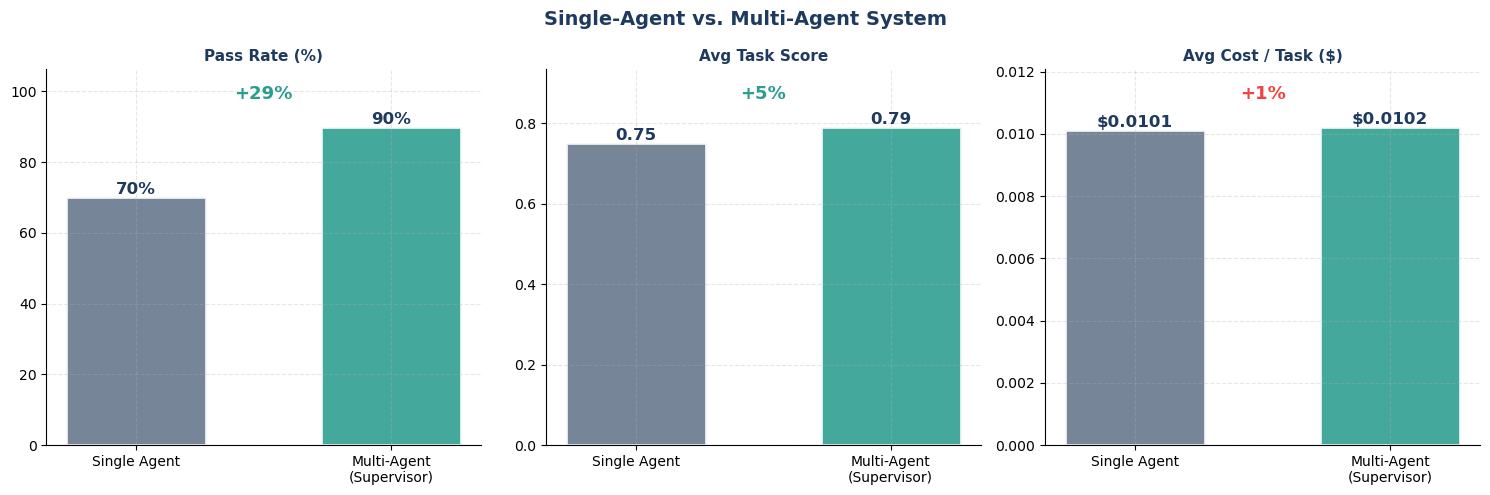

In [11]:
fig = plot_baseline_vs_multi(df_single, df_multi,
                            save_path=Config.OUTPUT_DIR / 'baseline_vs_multi.png')

In [12]:
# Auto-generated interpretation of the run
d_score = _avg(df_multi,'task_score') - _avg(df_single,'task_score')
d_cost  = _avg(df_multi,'total_cost') - _avg(df_single,'total_cost')
cost_x  = _avg(df_multi,'total_cost') / max(_avg(df_single,'total_cost'), 1e-9)

print('INTERPRETATION')
print('-'*60)
print(f"Task score:  {'MAS higher' if d_score>0 else 'Single higher'} by {abs(d_score):.3f}")
print(f"Cost:        MAS is {cost_x:.1f}x the single-agent cost (+${d_cost:.4f}/task)")
if d_score > 0.02:
    print('\n→ The Multi-Agent System improved task quality. The extra cost')
    print('  buys better planning and an independent validation check —')
    print('  worth it for complex, multi-step tasks.')
elif d_score < -0.02:
    print('\n→ The single agent matched or beat the MAS here. For tasks this')
    print('  simple, orchestration adds cost without a quality payoff.')
else:
    print('\n→ Quality is comparable on this sample. The MAS advantage grows')
    print('  with task complexity — try a harder task slice to see it widen.')

INTERPRETATION
------------------------------------------------------------
Task score:  MAS higher by 0.040
Cost:        MAS is 1.0x the single-agent cost (+$0.0001/task)

→ The Multi-Agent System improved task quality. The extra cost
  buys better planning and an independent validation check —
  worth it for complex, multi-step tasks.


## Step 10 — Observability Deep-Dive (OpenTelemetry)

The other half of the showcase. `hier_tracer` now holds the **multi-agent** spans
from Step 8. Every span carries GenAI Semantic Convention attributes
(`gen_ai.agent.name`, `gen_ai.agent.role`, `gen_ai.request.model`, `gen_ai.usage.*`)
and the export is **OTLP-compliant JSON** — drop it straight into Datadog, Splunk,
Phoenix, Langfuse, or Jaeger.

```
task.execute
├── agent.supervisor.route
├── agent.planner.plan        (role=task_decomposer)
├── agent.navigator.execute   (role=tool_executor)
│   ├── tool.execute
│   └── tool.execute
└── agent.validator.validate  (role=quality_checker)
```

Trace stats: {'total_traces': 10, 'total_spans': 166, 'avg_spans_per_trace': 16.6, 'errors': 0}


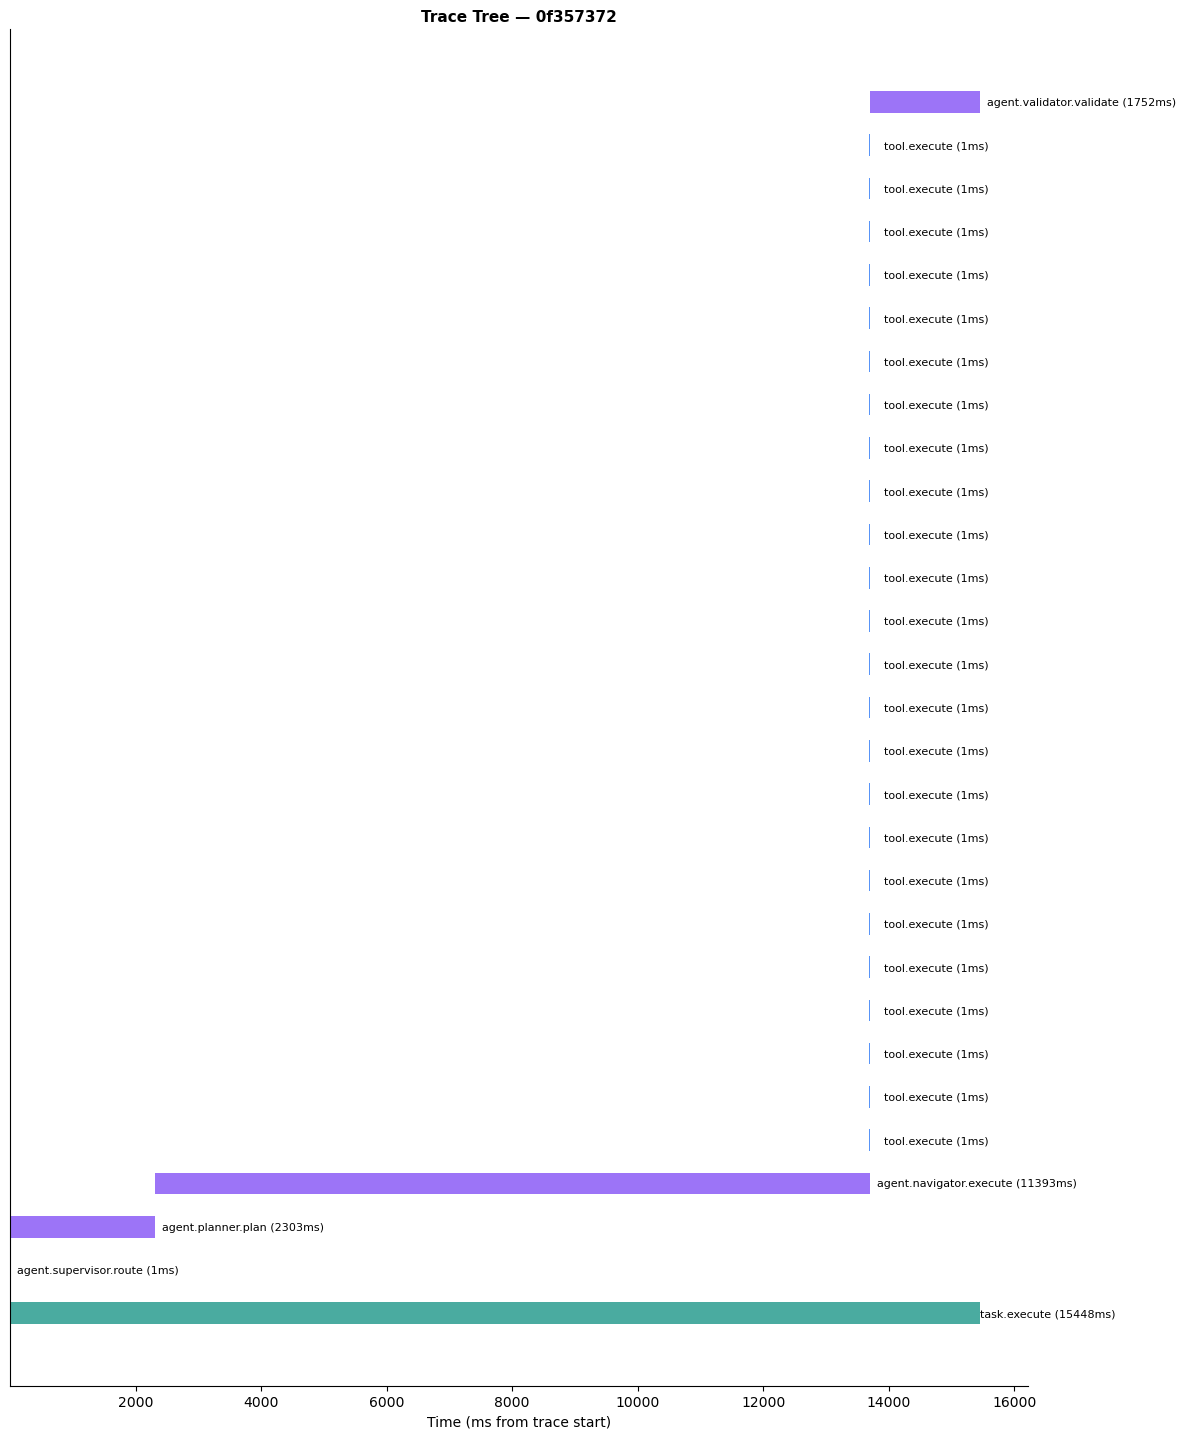

In [13]:
# Render the multi-agent trace tree for the first task
first_id = list(hier_tracer.traces.keys())[0]
fig = plot_trace_tree(hier_tracer, first_id, save_path=Config.OUTPUT_DIR / 'mas_trace_tree.png')

# Span + cost stats across the run
print('Trace stats:', hier_tracer.get_stats())

In [14]:
# Export all spans to OTLP JSON (portable to any OTel backend)
path = hier_tracer.save_all_traces(Config.TRACE_DIR)
print(f'OTLP traces exported → {path}')

OTLP traces exported → outputs/traces/all_otel_traces.jsonl


## Step 11 — Dashboards

Per-system evaluation and telemetry dashboards: score distribution, pass/fail,
tool-F1, cost-vs-latency, token usage, and rolling pass-rate.

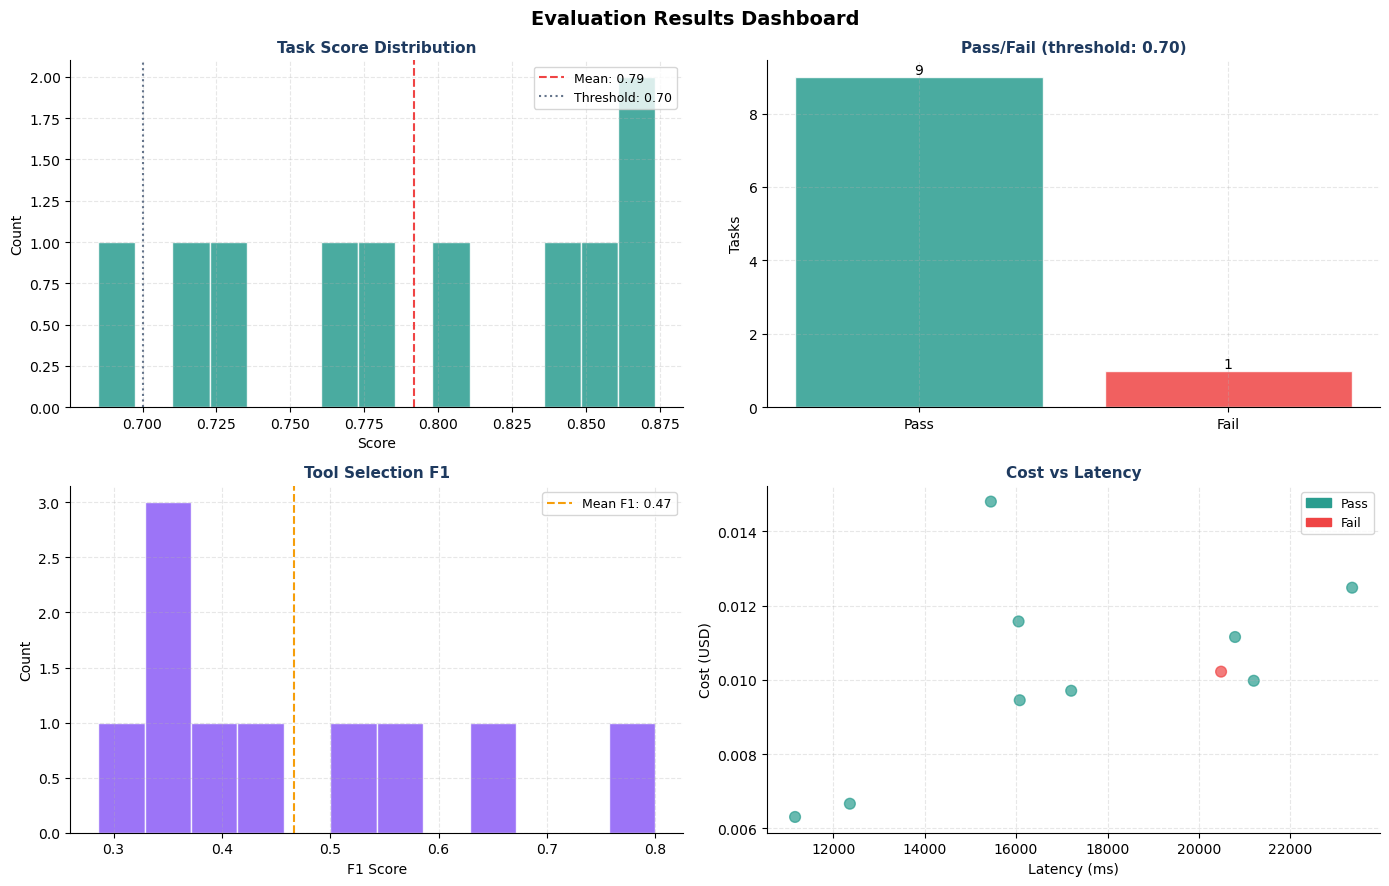

In [15]:
fig = plot_eval_dashboard(df_multi, threshold=Config.EVAL_PASS_THRESHOLD,
                          save_path=Config.OUTPUT_DIR / 'mas_eval_dashboard.png')

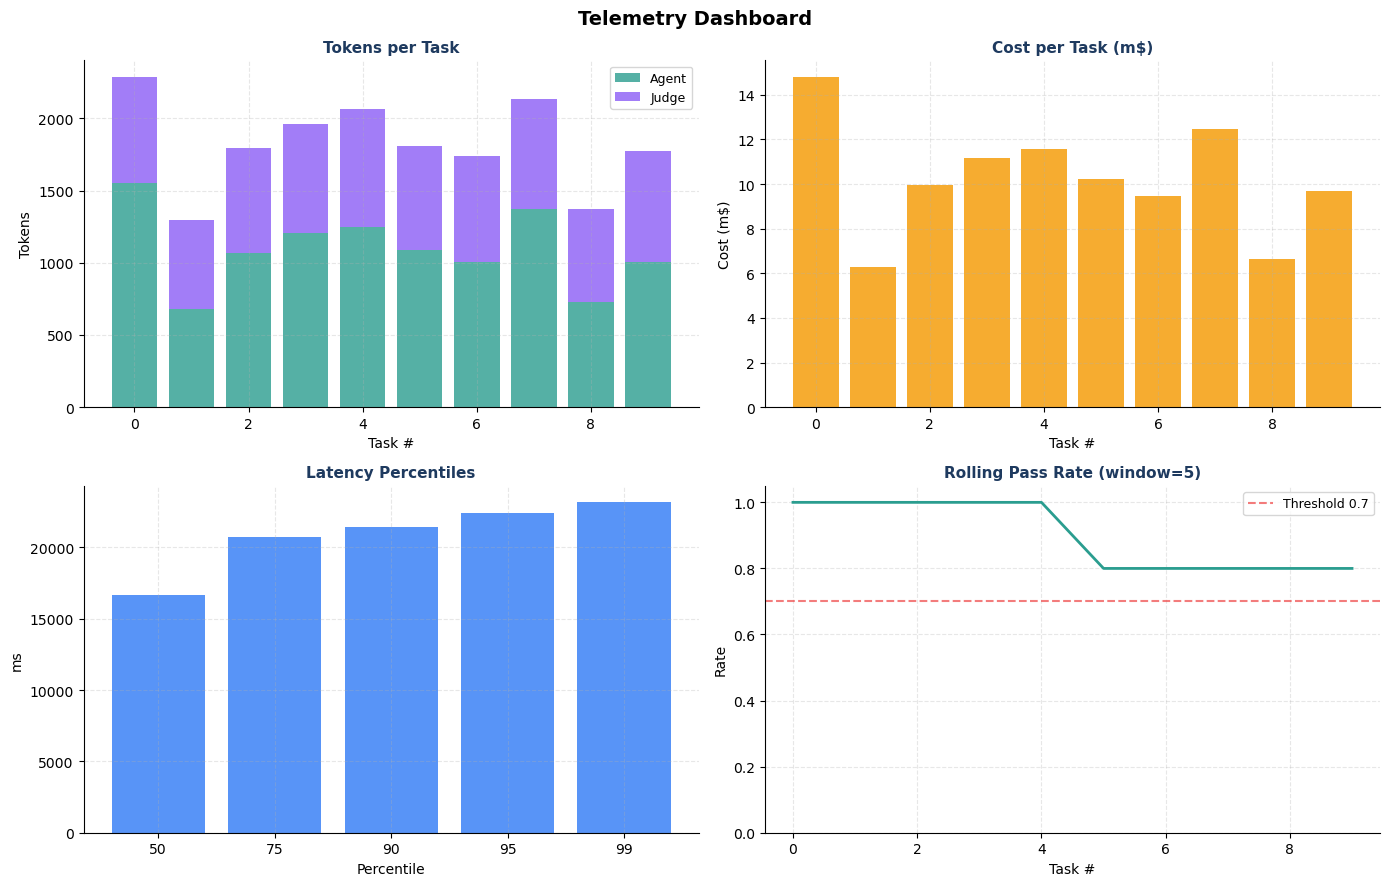

In [16]:
fig = plot_telemetry_dashboard(df_multi, save_path=Config.OUTPUT_DIR / 'mas_telemetry.png')

## Step 12 — Save Results

Persist both result tables and the cost summary. PNG dashboards and OTLP traces are
already in `outputs/` (git-ignored, so results stay local).

In [17]:
from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

df_single.to_csv(Config.OUTPUT_DIR / f'single_agent_{ts}.csv', index=False)
df_multi.to_csv(Config.OUTPUT_DIR / f'multi_agent_{ts}.csv', index=False)
comparison.to_csv(Config.OUTPUT_DIR / f'comparison_{ts}.csv')

print(f'Saved results → {Config.OUTPUT_DIR}')
print('\nCost summary (single-agent run):')
print(cost_tracker.get_summary())

Saved results → outputs

Cost summary (single-agent run):
{'total_cost': 0.1012405, 'avg_cost_per_task': 0.010124049999999999, 'median_cost': 0.008410250000000001, 'total_tokens': 8919, 'cost_by_model': {'gpt-5-4-20260305-gs': 0.1012405}, 'tokens_by_model': {'gpt-5-4-20260305-gs': 8919}}


## Step 13 — Audit-Grade Evaluation Report

Generate a structured Markdown report that consolidates the entire run into a
document suitable for model-risk review:

| Section | Contents |
|---|---|
| **1. Executive Summary** | Key findings & observations |
| **2. Testing Scope** | What we test · test data (Mind2Web) · regulations & compliance (SR 11-7, NIST AI RMF, EU AI Act, OTel SemConv) |
| **3. Testing Approach** | Hybrid sandbox method · scoring stack · judge model |
| **4. Testing Results** | Section-by-section: task completion, tool correctness, safety, cost/performance, single-vs-multi, observability — each with an **assessment** and an embedded **visualization** |
| **5. Conclusion** | Recommendation based on the cost/quality trade-off |
| **6. Appendices** | Artifacts, per-task **audit trail**, AI disclosure |

**Hybrid assessment.** Verdicts are **rule-based by default** (deterministic, audit-safe).
When a judge LLM is supplied, an extra narrative is added — clearly labeled
**🤖 AI Assessment** with a disclosure notice, so LLM inference is never confused with
the deterministic metrics. The saved `.md` (in `outputs/`) renders the embedded charts.

In [ ]:
from src import generate_report
from IPython.display import Markdown, display

# judge_llm enables the 🤖 AI Assessment blocks (set judge_llm=None for
# deterministic, rule-based-only assessments).
report_path = generate_report(
    df_single, df_multi, comparison,
    config=Config,
    judge_llm=judge_llm,
    tracer=hier_tracer,
    output_dir=Config.OUTPUT_DIR,
)
print(f'📄 Report saved → {report_path}')

# Preview in the notebook (open the .md in outputs/ to see embedded charts)
display(Markdown(report_path.read_text()))